<div style="background:linear-gradient(135deg,#78350f 0%,#d97706 55%,#f59e0b 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 57 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Freight Weights &amp; the Central Limit Theorem 📦</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Individual package weights are skewed. Yet the AVERAGE weight of a truckload is beautifully normal. We grow the real data into a large population, then sample from it again and again to watch the Central Limit Theorem take hold.</div>
  <div style="margin-top:16px;font-size:13px;color:#fed7aa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
AMBER="#d97706"; TEAL="#0d9488"; INK="#1a2138"; GRID="#e6e9f2"; PINK="#db2777"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/logistics_freight_operations.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"logistics_freight_operations.csv")
print("loaded:", df.shape)
df.head()

loaded: (1000, 4)


,truck_id,route_id,driver_id,individual_package_weight_lbs
0,TRK_4000,RT_I10,DRV_124,19.73
1,TRK_4001,RT_I95,DRV_127,15.54
2,TRK_4002,RT_I95,DRV_147,10.08
3,TRK_4003,RT_I80,DRV_148,8.69
4,TRK_4004,RT_I80,DRV_125,17.86


<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 1 · GROW THE DATA INTO A POPULATION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A large, skewed world to sample from</div>
<div style="color:#4a5578;margin-top:6px">The 1,000 sampled weights are right-skewed. To show the CLT we need a big population to draw from, so we fit a gamma to the data and generate a 1,000,000-package population with the same skewed shape.</div>
</div>

In [2]:
w = df["individual_package_weight_lbs"]
print(f"sample of weights: n={len(w)}, mean={w.mean():.2f}, sd={w.std():.2f}, skew={stats.skew(w):.3f} (right-skewed)")
# fit a gamma by method of moments and generate a large population
a = w.mean()**2/w.var(); b = w.var()/w.mean()
rng = np.random.default_rng(57)
POP = rng.gamma(a, b, size=1_000_000)
MU, SIG = POP.mean(), POP.std()
print(f"generated population: N=1,000,000, mu={MU:.3f}, sigma={SIG:.3f}, skew={stats.skew(POP):.3f}")

sample of weights: n=1000, mean=15.07, sd=4.00, skew=0.527 (right-skewed)
generated population: N=1,000,000, mu=15.073, sigma=4.001, skew=0.532


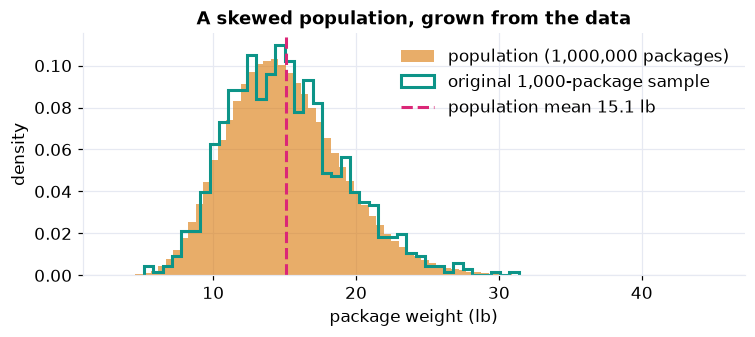

In [3]:
fig,ax=plt.subplots(figsize=(7,3.2))
ax.hist(POP,bins=80,density=True,color=AMBER,alpha=0.6,label="population (1,000,000 packages)")
ax.hist(w,bins=40,density=True,histtype="step",color=TEAL,lw=2,label="original 1,000-package sample")
ax.axvline(MU,color=PINK,ls="--",lw=2,label=f"population mean {MU:.1f} lb")
ax.set_xlabel("package weight (lb)"); ax.set_ylabel("density"); ax.set_title("A skewed population, grown from the data"); ax.legend()
plt.tight_layout(); plt.show()

The generated population matches the real data's right-skew (skew &#8776; 0.5), and gives us a large world to sample from. Its parameters, &#956; &#8776; 15 lb and &#963; &#8776; 4 lb, are the truth the Central Limit Theorem will reveal through sample means.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 2 · WATCH THE CLT TAKE HOLD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Sample means turn normal as n grows</div>
<div style="color:#4a5578;margin-top:6px">Draw many samples of size n, compute each mean, and look at the distribution of those means. For n=1 it is the skewed population; as n climbs to 30 and beyond, it becomes a clean normal, the Central Limit Theorem.</div>
</div>

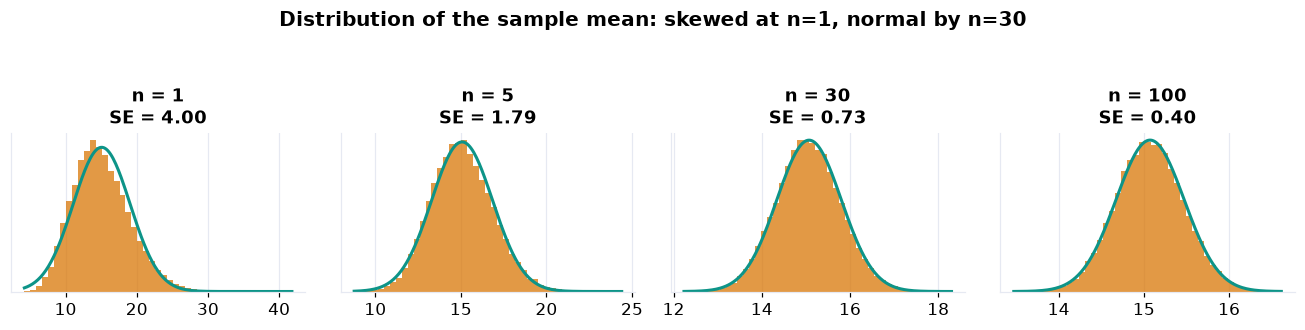

In [4]:
def sample_means(n, reps=40_000): return POP[rng.integers(0,len(POP),size=(reps,n))].mean(axis=1)
fig,axes=plt.subplots(1,4,figsize=(12,2.8))
for ax,n in zip(axes,[1,5,30,100]):
    means=sample_means(n)
    ax.hist(means,bins=45,density=True,color=AMBER,alpha=0.75)
    xs=np.linspace(means.min(),means.max(),200); ax.plot(xs,stats.norm.pdf(xs,MU,SIG/np.sqrt(n)),color=TEAL,lw=2)
    ax.set_title(f"n = {n}\nSE = {SIG/np.sqrt(n):.2f}"); ax.set_yticks([])
fig.suptitle("Distribution of the sample mean: skewed at n=1, normal by n=30", y=1.06, fontweight="bold")
plt.tight_layout(); plt.show()

In [5]:
for n in [1,5,30,100]:
    means=sample_means(n)
    print(f"n={n:3d}: mean of means {means.mean():.3f} (mu {MU:.3f}), SE {means.std():.3f} (sigma/sqrt(n) {SIG/np.sqrt(n):.3f}), skew {stats.skew(means):+.3f}")

n=  1: mean of means 15.075 (mu 15.073), SE 3.977 (sigma/sqrt(n) 4.001), skew +0.501
n=  5: mean of means 15.063 (mu 15.073), SE 1.782 (sigma/sqrt(n) 1.789), skew +0.241
n= 30: mean of means 15.070 (mu 15.073), SE 0.730 (sigma/sqrt(n) 0.730), skew +0.086
n=100: mean of means 15.073 (mu 15.073), SE 0.400 (sigma/sqrt(n) 0.400), skew +0.059


The transformation is dramatic: at n=1 the means inherit the population's skew (+0.5), but by **n=30** the skew is essentially zero and the bell is textbook. The spread shrinks exactly as **SE = &#963;/&#8730;n**, halving each time n quadruples. This is the CLT: averages of a skewed population are normal.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 3 · THE PAYOFF: A CONFIDENCE INTERVAL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">From one truckload to a guarantee</div>
<div style="color:#4a5578;margin-top:6px">Because the sample mean is normal with known SE, a single truckload of n packages yields a confidence interval for the average fleet weight, the whole reason the CLT matters for inference.</div>
</div>

In [6]:
n = 50; SE = SIG/np.sqrt(n)
truck = rng.choice(POP, n, replace=False)
xbar = truck.mean()
lo, hi = xbar - 1.96*SE, xbar + 1.96*SE
print(f"one truckload of {n}: sample mean = {xbar:.2f} lb")
print(f"95% CI for fleet mean weight = [{lo:.2f}, {hi:.2f}]  (true mu = {MU:.2f})")
# coverage check
cov=np.mean([(lambda m: m-1.96*SE<=MU<=m+1.96*SE)(rng.choice(POP,n,replace=False).mean()) for _ in range(5000)])
print(f"coverage of 95% CIs over 5000 truckloads = {cov*100:.1f}%")

one truckload of 50: sample mean = 14.52 lb
95% CI for fleet mean weight = [13.41, 15.63]  (true mu = 15.07)
coverage of 95% CIs over 5000 truckloads = 94.8%


A single truckload of 50 packages pins the fleet's average weight to within about &plusmn;1 lb with 95% confidence, and across thousands of truckloads those intervals capture the true mean about **95%** of the time. The CLT is what turns one skewed sample into a reliable, normal-based guarantee, the bridge from this Part to all of statistical inference.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Case closed</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Individual weights are skewed, but their averages are normal. We grew the data into a million-package population, sampled it repeatedly to watch sample means turn normal by n=30 with SE = &#963;/&#8730;n, and used that to build a 95% confidence interval for the fleet mean. The CLT is the engine behind the t-test, chi-square, and ANOVA that follow.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>